# 05 모델링

`modeling_dataset.csv`를 사용해 다음 월 평균 매매가를 예측한다.

- Baseline 모델과 Full 모델 비교
- Linear Regression, Decision Tree Regressor, Random Forest Regressor 성능 비교
- 실제값 vs 예측값 확인
- 가격 예측 변수 중요도 분석
- 예측 가격 대비 실제 가격 초과율 확인

In [28]:
from pathlib import Path
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "modeling_dataset.csv"
TABLE_DIR = ROOT / "outputs" / "tables"
FIG_DIR = ROOT / "outputs" / "figures" / "model"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

print("입력 파일:", DATA_PATH)
print("표 저장:", TABLE_DIR)
print("그림 저장:", FIG_DIR)

입력 파일: /Users/min/RealEstate-Risk-Radar/data/processed/modeling_dataset.csv
표 저장: /Users/min/RealEstate-Risk-Radar/outputs/tables
그림 저장: /Users/min/RealEstate-Risk-Radar/outputs/figures/model


In [29]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

df["contract_month"] = pd.to_datetime(df["contract_month"])
df = df.sort_values(["gu", "contract_month"]).reset_index(drop=True)

df["month_num"] = df["contract_month"].dt.month
df["year"] = df["contract_month"].dt.year

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (850, 61)


,sggCd,gu,contract_month,avg_sale_price,med_sale_price,avg_sale_price_per_m2,med_sale_price_per_m2,sale_count,avg_jeonse_deposit,med_jeonse_deposit,...,stagnation_score,stagnation_level,resident_risk_grade,investor_risk_grade,total_risk_score,risk_grade,warning_flag,risk_target,month_num,year
0,11680,강남구,2023-06-01,228844.322344,219000.0,2663.421804,2751.590856,273,82748.708333,70000.0,...,0.20,활발 관찰 구간,우선 점검 구간,우선 점검 구간,0.554477,높음,1,1,6,2023
1,11680,강남구,2023-07-01,231213.471545,214000.0,2623.794249,2696.871985,246,86057.539001,73000.0,...,0.45,안정 정체 구간,우선 점검 구간,신중 투자 구간,0.510198,높음,0,1,7,2023
2,11680,강남구,2023-08-01,232705.516014,212000.0,2612.997473,2722.987222,281,85542.612191,73000.0,...,0.45,안정 정체 구간,우선 점검 구간,신중 투자 구간,0.505715,높음,0,1,8,2023
3,11680,강남구,2023-09-01,213373.786408,200000.0,2538.890572,2544.302857,206,90637.708372,80000.0,...,0.45,안정 정체 구간,신중 매수 구간,신중 투자 구간,0.470862,주의,0,0,9,2023
4,11680,강남구,2023-10-01,252927.244898,220000.0,2709.602322,2745.621846,147,90321.675314,80000.0,...,0.45,안정 정체 구간,우선 점검 구간,우선 점검 구간,0.537492,높음,1,1,10,2023


In [30]:
target = "next_month_sale_price"

baseline_numeric_features = [
    "avg_sale_price",
    "avg_jeonse_deposit",
    "sale_count",
]

baseline_categorical_features = [
    "gu",
    "month_num",
    "year",
]

generated_features = [
    "jeonse_rate",
    "gap_rate",
    "sale_growth_1m",
    "jeonse_growth_1m",
    "growth_gap_1m",
    "sale_volume_growth_1m",
    "rent_volume_growth_1m",
    "monthly_ratio",
]

full_numeric_features = baseline_numeric_features + generated_features
full_categorical_features = baseline_categorical_features

required_cols = full_numeric_features + full_categorical_features + [target]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"누락 컬럼: {missing_cols}")

model_df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=required_cols).copy()

print("모델링 데이터 크기:", model_df.shape)
print("타깃 변수:", target)

모델링 데이터 크기: (850, 61)
타깃 변수: next_month_sale_price


In [31]:
unique_months = sorted(model_df["contract_month"].unique())
test_months = unique_months[-3:]

train_df = model_df[~model_df["contract_month"].isin(test_months)].copy()
test_df = model_df[model_df["contract_month"].isin(test_months)].copy()

print("학습 기간:", train_df["contract_month"].min().strftime("%Y-%m"), "~", train_df["contract_month"].max().strftime("%Y-%m"))
print("테스트 기간:", test_df["contract_month"].min().strftime("%Y-%m"), "~", test_df["contract_month"].max().strftime("%Y-%m"))
print("학습 데이터:", train_df.shape)
print("테스트 데이터:", test_df.shape)

학습 기간: 2023-06 ~ 2025-12
테스트 기간: 2026-01 ~ 2026-03
학습 데이터: (775, 61)
테스트 데이터: (75, 61)


In [32]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
}

def make_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

def evaluate_regression(y_true, y_pred):
    return {
        "MAE(만원)": mean_absolute_error(y_true, y_pred),
        "RMSE(만원)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE(%)": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
    }

def run_models(feature_set, numeric_features, categorical_features):
    X_train = train_df[numeric_features + categorical_features]
    y_train = train_df[target]

    X_test = test_df[numeric_features + categorical_features]
    y_test = test_df[target]

    rows = []
    fitted = {}

    for model_name, model in models.items():
        pipe = Pipeline([
            ("preprocess", make_preprocessor(numeric_features, categorical_features)),
            ("model", model),
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        scores = evaluate_regression(y_test, pred)

        rows.append({
            "feature_set": feature_set,
            "model": model_name,
            **scores,
        })

        fitted[model_name] = pipe

    return pd.DataFrame(rows), fitted

In [33]:
baseline_result, baseline_models = run_models(
    "Baseline",
    baseline_numeric_features,
    baseline_categorical_features
)

full_result, full_models = run_models(
    "Full",
    full_numeric_features,
    full_categorical_features
)

all_results = pd.concat([baseline_result, full_result], ignore_index=True)

all_results_round = all_results.copy()
all_results_round["MAE(만원)"] = all_results_round["MAE(만원)"].round(1)
all_results_round["RMSE(만원)"] = all_results_round["RMSE(만원)"].round(1)
all_results_round["R2"] = all_results_round["R2"].round(4)
all_results_round["MAPE(%)"] = all_results_round["MAPE(%)"].round(2)

price_prediction_comparison = all_results_round[all_results_round["feature_set"] == "Full"].drop(columns=["feature_set"])

all_results_round.to_csv(TABLE_DIR / "price_prediction_all_model_results.csv", index=False, encoding="utf-8-sig")
price_prediction_comparison.to_csv(TABLE_DIR / "price_prediction_comparison.csv", index=False, encoding="utf-8-sig")

price_prediction_comparison

,model,MAE(만원),RMSE(만원),R2,MAPE(%)
3,Linear Regression,10436.6,12780.7,0.9467,8.88
4,Decision Tree Regressor,11632.8,19157.1,0.8802,8.62
5,Random Forest Regressor,6371.9,10243.4,0.9657,4.78


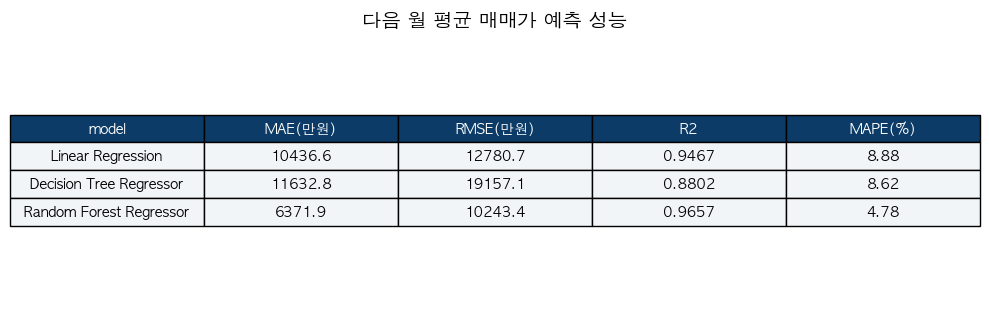

In [34]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")

table = ax.table(
    cellText=price_prediction_comparison.values,
    colLabels=price_prediction_comparison.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#0B3B66")
    else:
        cell.set_facecolor("#F2F5F7")

ax.set_title("다음 월 평균 매매가 예측 성능", fontsize=14, weight="bold", pad=12)

plt.tight_layout()
plt.savefig(FIG_DIR / "price_prediction_comparison_table.png", dpi=300, bbox_inches="tight")
plt.show()

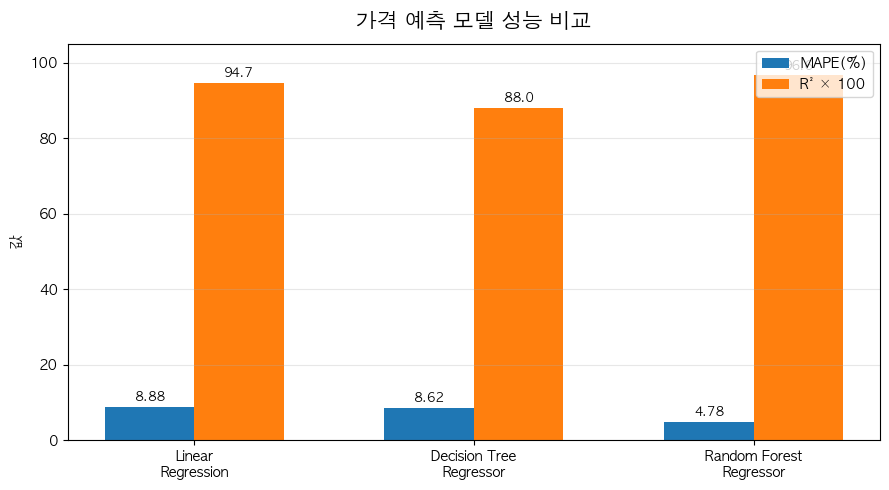

In [35]:
plot_df = price_prediction_comparison.copy()

model_labels = {
    "Linear Regression": "Linear\nRegression",
    "Decision Tree Regressor": "Decision Tree\nRegressor",
    "Random Forest Regressor": "Random Forest\nRegressor"
}

plot_df["model_label"] = plot_df["model"].map(model_labels)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_df))
width = 0.32

mape_bars = ax.bar(x - width / 2, plot_df["MAPE(%)"], width, label="MAPE(%)")
r2_bars = ax.bar(x + width / 2, plot_df["R2"] * 100, width, label="R² × 100")

ax.set_title("가격 예측 모델 성능 비교", fontsize=15, pad=12)
ax.set_ylabel("값", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_label"], fontsize=10)
ax.set_ylim(0, 105)
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", alpha=0.3)

for bar in mape_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in r2_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "price_prediction_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

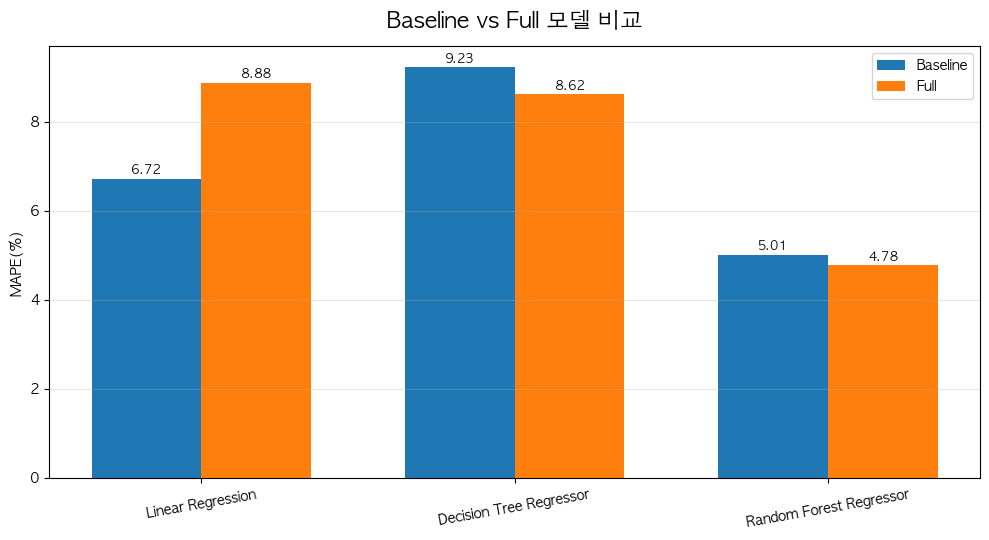

feature_set,model,Baseline,Full
0,Linear Regression,6.72,8.88
1,Decision Tree Regressor,9.23,8.62
2,Random Forest Regressor,5.01,4.78


In [36]:
baseline_full_mape = (
    all_results_round
    .pivot(index="model", columns="feature_set", values="MAPE(%)")
    .reset_index()
)

model_order = ["Linear Regression", "Decision Tree Regressor", "Random Forest Regressor"]
baseline_full_mape = baseline_full_mape.set_index("model").reindex(model_order).reset_index()

baseline_full_mape.to_csv(TABLE_DIR / "baseline_full_mape_comparison.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(baseline_full_mape))
width = 0.35

ax.bar(x - width / 2, baseline_full_mape["Baseline"], width, label="Baseline")
ax.bar(x + width / 2, baseline_full_mape["Full"], width, label="Full")

ax.set_title("Baseline vs Full 모델 비교", fontsize=16, pad=14)
ax.set_ylabel("MAPE(%)")
ax.set_xticks(x)
ax.set_xticklabels(baseline_full_mape["model"], rotation=10)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, row in baseline_full_mape.iterrows():
    ax.text(i - width / 2, row["Baseline"] + 0.1, f'{row["Baseline"]:.2f}', ha="center", fontsize=9)
    ax.text(i + width / 2, row["Full"] + 0.1, f'{row["Full"]:.2f}', ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_vs_full_mape.png", dpi=300, bbox_inches="tight")
plt.show()

baseline_full_mape

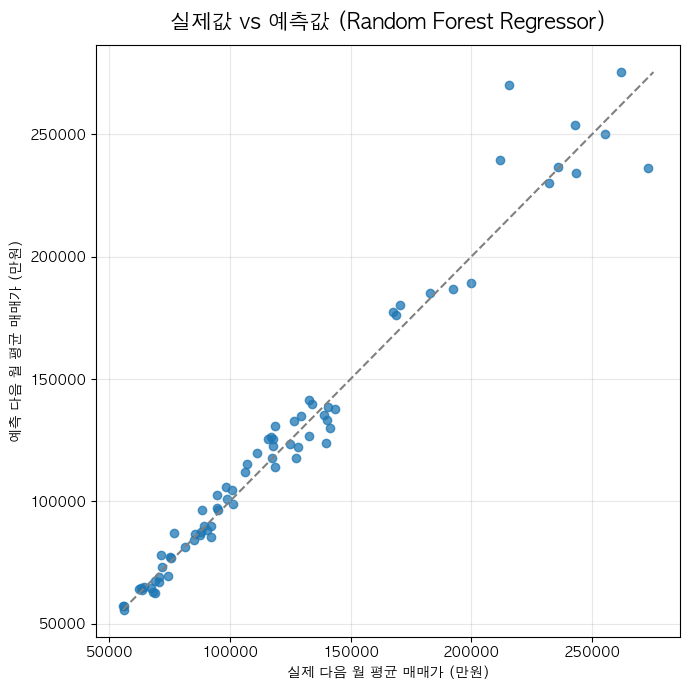

In [37]:
best_model_name = "Random Forest Regressor"
best_model = full_models[best_model_name]

X_test_full = test_df[full_numeric_features + full_categorical_features]
y_test = test_df[target]
y_pred = best_model.predict(X_test_full)

prediction_result = test_df[["gu", "contract_month", "avg_sale_price", target]].copy()
prediction_result["pred_next_month_sale_price"] = y_pred
prediction_result["prediction_error"] = prediction_result[target] - prediction_result["pred_next_month_sale_price"]
prediction_result["prediction_error_rate"] = prediction_result["prediction_error"] / prediction_result["pred_next_month_sale_price"] * 100

prediction_result.to_csv(TABLE_DIR / "price_prediction_test_predictions.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, y_pred, alpha=0.75)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

ax.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="gray")

ax.set_title("실제값 vs 예측값 (Random Forest Regressor)", fontsize=15, pad=12)
ax.set_xlabel("실제 다음 월 평균 매매가 (만원)")
ax.set_ylabel("예측 다음 월 평균 매매가 (만원)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "price_prediction_actual_vs_pred.png", dpi=300, bbox_inches="tight")
plt.show()

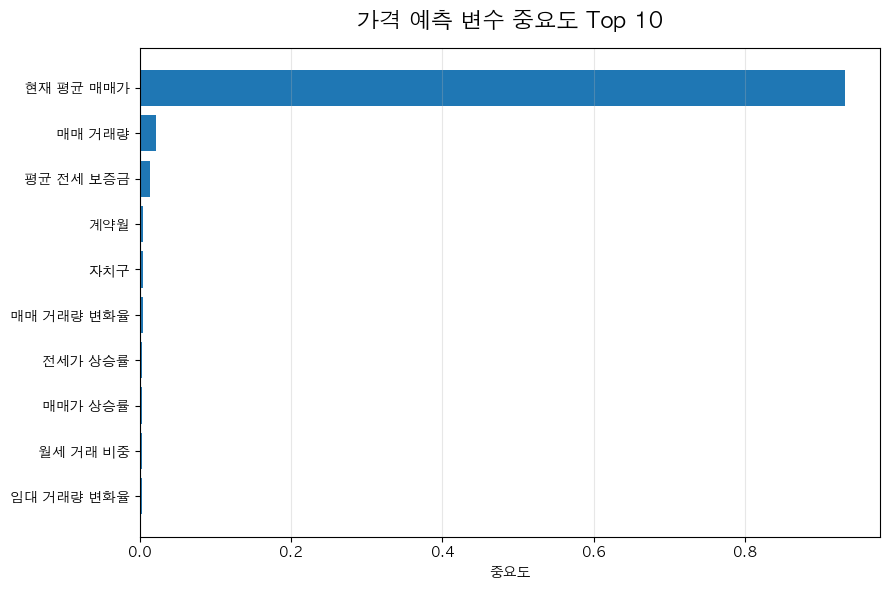

,feature_clean,importance,feature_label
1,avg_sale_price,0.931639,현재 평균 매매가
8,sale_count,0.020914,매매 거래량
0,avg_jeonse_deposit,0.013920,평균 전세 보증금
12,계약월,0.004356,계약월
13,자치구,0.004306,자치구
10,sale_volume_growth_1m,0.003899,매매 거래량 변화율
4,jeonse_growth_1m,0.003331,전세가 상승률
9,sale_growth_1m,0.003185,매매가 상승률
6,monthly_ratio,0.003040,월세 거래 비중
7,rent_volume_growth_1m,0.002566,임대 거래량 변화율


In [38]:
rf_model = full_models["Random Forest Regressor"]
rf_regressor = rf_model.named_steps["model"]
preprocessor = rf_model.named_steps["preprocess"]

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_regressor.feature_importances_,
})

def clean_feature_name(name):
    name = name.replace("num__", "").replace("cat__", "")
    if name.startswith("gu_"):
        return "자치구"
    if name.startswith("month_num_"):
        return "계약월"
    if name.startswith("year_"):
        return "계약연도"
    return name

importance_df["feature_clean"] = importance_df["feature"].apply(clean_feature_name)

importance_grouped = (
    importance_df
    .groupby("feature_clean", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

feature_label_map = {
    "avg_sale_price": "현재 평균 매매가",
    "avg_jeonse_deposit": "평균 전세 보증금",
    "sale_count": "매매 거래량",
    "jeonse_rate": "전세가율",
    "gap_rate": "괴리율",
    "sale_growth_1m": "매매가 상승률",
    "jeonse_growth_1m": "전세가 상승률",
    "growth_gap_1m": "상승률 차이",
    "sale_volume_growth_1m": "매매 거래량 변화율",
    "rent_volume_growth_1m": "임대 거래량 변화율",
    "monthly_ratio": "월세 거래 비중",
    "자치구": "자치구",
    "계약월": "계약월",
    "계약연도": "계약연도",
}

importance_grouped["feature_label"] = importance_grouped["feature_clean"].map(feature_label_map).fillna(importance_grouped["feature_clean"])

importance_grouped.to_csv(TABLE_DIR / "price_prediction_feature_importance.csv", index=False, encoding="utf-8-sig")

top_importance = importance_grouped.head(10).copy()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_importance["feature_label"][::-1], top_importance["importance"][::-1])

ax.set_title("가격 예측 변수 중요도 Top 10", fontsize=16, pad=14)
ax.set_xlabel("중요도")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "price_prediction_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

top_importance

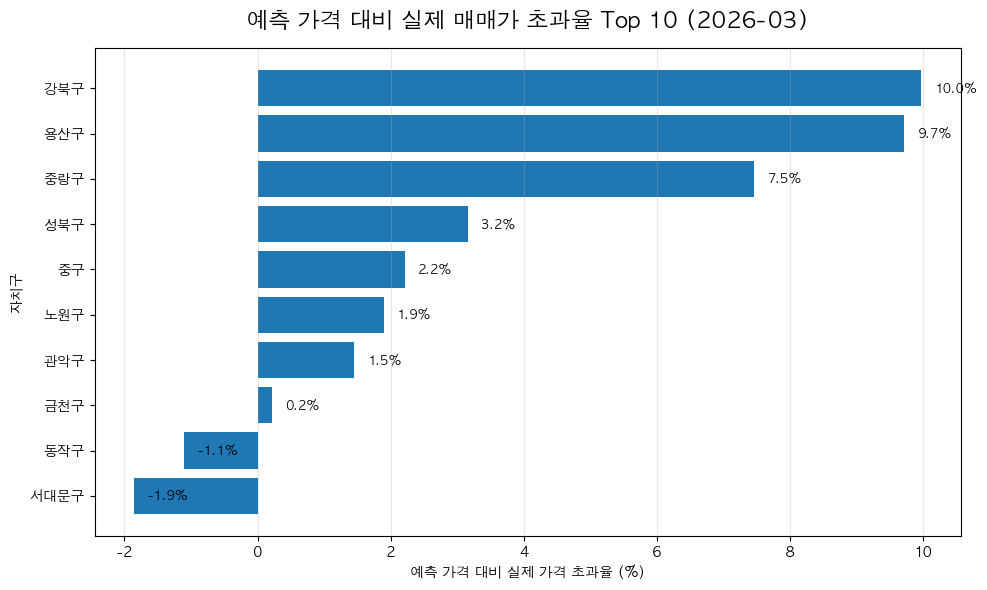

,gu,contract_month,avg_sale_price,pred_supported_sale_price,price_support_gap_rate
101,강북구,2026-03-01,71769.064748,65259.661162,9.974621
713,용산구,2026-03-01,243613.750000,222040.431246,9.715942
849,중랑구,2026-03-01,69188.197425,64383.418870,7.462758
577,성북구,2026-03-01,88616.184971,85903.622248,3.157681
815,중구,2026-03-01,118906.020408,116334.849755,2.210147
305,노원구,2026-03-01,64385.790173,63188.308189,1.895101
169,관악구,2026-03-01,85537.568807,84313.485966,1.451823
271,금천구,2026-03-01,62429.565217,62293.465861,0.218481
407,동작구,2026-03-01,140438.793103,142001.767519,-1.100673
475,서대문구,2026-03-01,101507.154812,103424.456193,-1.853818


In [39]:
support_features = [
    "avg_jeonse_deposit",
    "sale_count",
    "jeonse_rate",
    "gap_rate",
    "sale_growth_1m",
    "jeonse_growth_1m",
    "growth_gap_1m",
    "sale_volume_growth_1m",
    "rent_volume_growth_1m",
    "monthly_ratio",
]

support_required = support_features + ["avg_sale_price", "gu", "month_num"]
support_df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=support_required).copy()

latest_month = support_df["contract_month"].max()

train_support = support_df[support_df["contract_month"] < latest_month].copy()
latest_support = support_df[support_df["contract_month"] == latest_month].copy()

support_model = Pipeline([
    ("preprocess", make_preprocessor(support_features, ["gu", "month_num"])),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
])

support_model.fit(
    train_support[support_features + ["gu", "month_num"]],
    train_support["avg_sale_price"]
)

latest_support["pred_supported_sale_price"] = support_model.predict(
    latest_support[support_features + ["gu", "month_num"]]
)

latest_support["price_support_gap_rate"] = (
    (latest_support["avg_sale_price"] - latest_support["pred_supported_sale_price"])
    / latest_support["pred_supported_sale_price"]
    * 100
)

price_support_gap_summary = latest_support[[
    "gu",
    "contract_month",
    "avg_sale_price",
    "pred_supported_sale_price",
    "price_support_gap_rate",
]].copy()

price_support_gap_summary = price_support_gap_summary.sort_values("price_support_gap_rate", ascending=False)
price_support_gap_top10 = price_support_gap_summary.head(10).copy()

price_support_gap_summary.to_csv(TABLE_DIR / "price_support_gap_summary.csv", index=False, encoding="utf-8-sig")
price_support_gap_top10.to_csv(TABLE_DIR / "price_support_gap_top10.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    price_support_gap_top10["gu"][::-1],
    price_support_gap_top10["price_support_gap_rate"][::-1]
)

ax.set_title(f"예측 가격 대비 실제 매매가 초과율 Top 10 ({latest_month.strftime('%Y-%m')})", fontsize=16, pad=14)
ax.set_xlabel("예측 가격 대비 실제 가격 초과율 (%)")
ax.set_ylabel("자치구")
ax.grid(axis="x", alpha=0.3)

for i, value in enumerate(price_support_gap_top10["price_support_gap_rate"][::-1]):
    ax.text(value + 0.2, i, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "price_support_gap_top10.png", dpi=300, bbox_inches="tight")
plt.show()

price_support_gap_top10

In [40]:
print("표 파일")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(path.name)

print("\n그림 파일")
for path in sorted(FIG_DIR.glob("*.png")):
    print(path.name)

표 파일
baseline_full_mape_comparison.csv
price_prediction_all_model_results.csv
price_prediction_comparison.csv
price_prediction_feature_importance.csv
price_prediction_test_predictions.csv
price_support_gap_summary.csv
price_support_gap_top10.csv

그림 파일
baseline_vs_full_mape.png
price_prediction_actual_vs_pred.png
price_prediction_comparison_table.png
price_prediction_feature_importance.png
price_prediction_model_comparison.png
price_support_gap_top10.png
